## Complexity & Profiling

This notebook covers two deeply connected topics: **how to reason about the cost of code** and **how to measure it in practice**.

## Outline

**Part A — Algorithmic Complexity**
1. What is Big-O? The mental model
2. O(1) — Constant Time
3. O(log n) — Logarithmic Time
4. O(n) — Linear Time
5. O(n²) and O(n^k) — Polynomial Time
6. O(2^n) and O(n!) — Exponential & Factorial Time
7. Visualising All Classes Together

**Part B — Profiling Tools**

8. `timeit` — Quick Benchmarking
9. `pyinstrument` — Call-Stack Profiling
10. `line_profiler` — Line-by-Line Profiling

**Part C — Optimisation Challenges**

11. Intermediate Optimisation Exercises


In [4]:
# ── Setup: install profiling tools if needed ──────────────────────────────────
# Run this cell once before anything else.

import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

install("pyinstrument")
install("line_profiler")
install("matplotlib")

print("All packages ready.")

All packages ready.


In [3]:
# ── Shared imports used throughout the notebook ────────────────────────────────

import time
import timeit
import random
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Notebook-wide plot style
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

print("Imports OK.")

Imports OK.


## PART A — Algorithmic Complexity

## 1. What Is Big-O? The Mental Model

**Big-O notation** describes how the *runtime* of an algorithm **grows** as the input size `n` grows.

It answers: **"If I double the input, what happens to the runtime (cost)?"**

### Key rules
1. **Drop constants** — O(3n) → O(n). We care about shape, not exact counts.
2. **Drop lower-order terms** — O(n² + n) → O(n²). The dominant term wins.
3. **Worst case** — Big-O usually describes the worst scenario unless stated otherwise.
4. **n is the size of the input** — a list of 1000 items has n = 1000.

### Complexity classes (fastest → slowest for large n)

| Class | Name | Example |
|---|---|---|
| O(1) | Constant | Dict lookup, list index |
| O(log n) | Logarithmic | Binary search |
| O(n) | Linear | Linear search, single loop |
| O(n log n) | Linearithmic | Merge sort, Timsort |
| O(n²) | Quadratic | Bubble sort, nested loops |
| O(2ⁿ) | Exponential | Naive recursion (Fibonacci) |
| O(n!) | Factorial | Brute-force permutations |

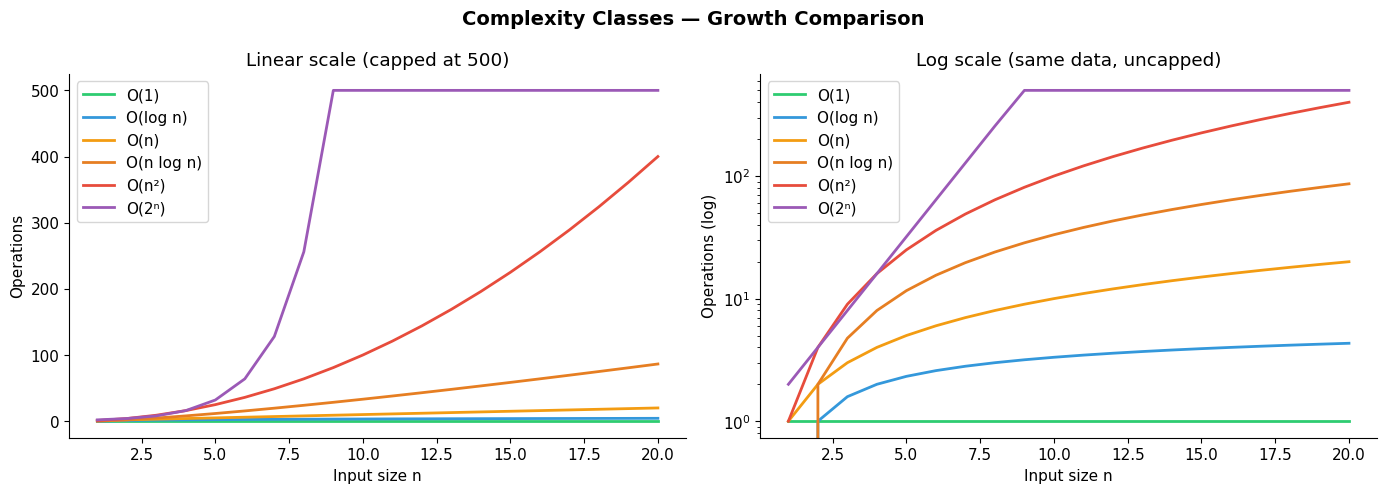

In [5]:
# ── Visual intuition: how fast do complexity classes grow? ─────────────────────

ns = np.arange(1, 21)   # n from 1 to 20

curves = {
    "O(1)":      np.ones_like(ns, dtype=float),
    "O(log n)":  np.log2(ns.astype(float)),
    "O(n)":      ns.astype(float),
    "O(n log n)": ns * np.log2(ns.astype(float)),
    "O(n²)":     ns.astype(float) ** 2,
    "O(2ⁿ)":     2.0 ** ns,
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#2ecc71", "#3498db", "#f39c12", "#e67e22", "#e74c3c", "#9b59b6"]

for (label, values), color in zip(curves.items(), colors):
    capped = np.minimum(values, 500)
    ax1.plot(ns, capped, label=label, color=color, linewidth=2)
    ax2.plot(ns, capped, label=label, color=color, linewidth=2)

ax1.set_title("Linear scale (capped at 500)")
ax1.set_xlabel("Input size n")
ax1.set_ylabel("Operations")
ax1.legend(loc="upper left")

ax2.set_yscale("log")
ax2.set_title("Log scale (same data, uncapped)")
ax2.set_xlabel("Input size n")
ax2.set_ylabel("Operations (log)")
ax2.legend(loc="upper left")

plt.suptitle("Complexity Classes — Growth Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 2. O(1) — Constant Time

An algorithm is **O(1)** if it takes the same amount of time **regardless of input size**.

No matter if your list has 10 or 10,000,000 elements — the operation takes the same time.

**Common O(1) operations in Python:**
- `my_list[i]` — index access
- `my_dict[key]` — dictionary lookup
- `my_set.add(x)` — set insertion
- `len(my_list)` — Python stores length as a field
- `deque.appendleft(x)` — front insertion on a deque (if you don't know, what this is: look it up!)

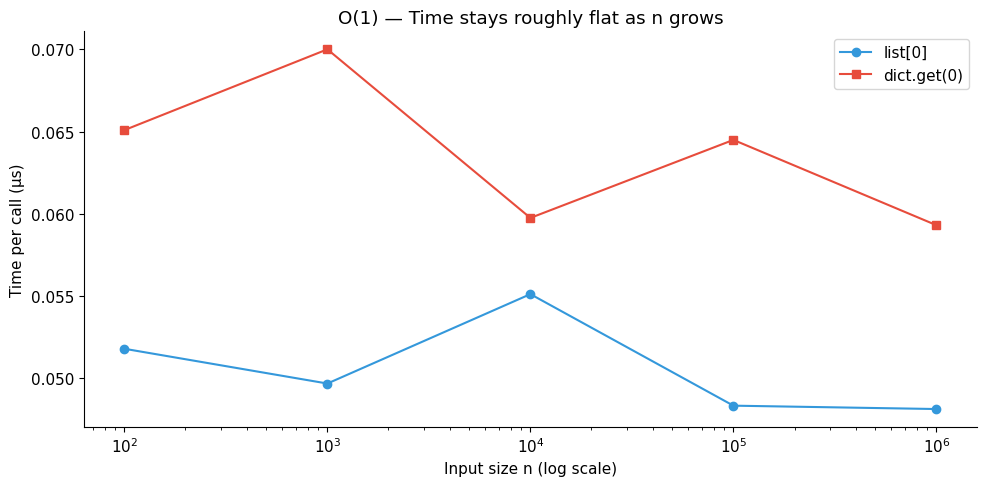


Times (µs):
  n=      100  list[0]: 0.0518µs   dict.get: 0.0651µs
  n=    1,000  list[0]: 0.0497µs   dict.get: 0.0700µs
  n=   10,000  list[0]: 0.0551µs   dict.get: 0.0598µs
  n=  100,000  list[0]: 0.0483µs   dict.get: 0.0645µs
  n=1,000,000  list[0]: 0.0481µs   dict.get: 0.0593µs


In [6]:
# Example 1: O(1) operations — timing stays flat as n grows

def get_first(lst):
    """O(1) — doesn't matter how long lst is."""
    return lst[0]

def dict_lookup(d, key):
    """O(1) — hash table lookup."""
    return d.get(key)

sizes = [100, 1_000, 10_000, 100_000, 1_000_000]
times_list = []
times_dict = []

for n in sizes:
    lst = list(range(n))
    d   = {i: i for i in range(n)}

    t_list = timeit.timeit(lambda: get_first(lst),     number=50_000) / 50_000
    t_dict = timeit.timeit(lambda: dict_lookup(d, 0),  number=50_000) / 50_000

    times_list.append(t_list * 1e6)   # µs
    times_dict.append(t_dict * 1e6)

fig, ax = plt.subplots()
ax.plot(sizes, times_list, "o-", label="list[0]",     color="#3498db")
ax.plot(sizes, times_dict, "s-", label="dict.get(0)", color="#e74c3c")
ax.set_xscale("log")
ax.set_xlabel("Input size n (log scale)")
ax.set_ylabel("Time per call (µs)")
ax.set_title("O(1) — Time stays roughly flat as n grows")
ax.legend()
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
plt.tight_layout()
plt.show()

print("\nTimes (µs):")
for n, tl, td in zip(sizes, times_list, times_dict):
    print(f"  n={n:>9,}  list[0]: {tl:.4f}µs   dict.get: {td:.4f}µs")

## 3. O(log n) — Logarithmic Time

An algorithm is **O(log n)** if it **halves the problem size** on each step.

Doubling `n` only adds **one extra step** — this is extraordinarily scalable.

| n | log₂(n) steps |
|---|---|
| 8 | 3 |
| 1,024 | 10 |
| 1,000,000 | ~20 |
| 1,000,000,000 | ~30 |

**Classic example:** binary search — find a value in a *sorted* list by always checking the midpoint.

In [7]:
# Example 1: Binary search — O(log n)

def binary_search(arr, target):
    """Search sorted arr for target. Returns index or -1."""
    low, high = 0, len(arr) - 1
    steps = 0
    while low <= high:
        steps += 1
        mid = (low + high) // 2
        if arr[mid] == target:
            return mid, steps
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    return -1, steps

# Show step count growing logarithmically
print(f"{'n':>15}  {'steps':>8}  {'log₂(n)':>10}")
print("-" * 38)
for n in [8, 64, 1_000, 1_000_000, 1_000_000_000]:
    arr = list(range(n))
    # Search for worst-case target (not present)
    _, steps = binary_search(arr, n + 1)
    print(f"  {n:>13,}  {steps:>8}  {math.log2(n):>10.1f}")

              n     steps     log₂(n)
--------------------------------------
              8         4         3.0
             64         7         6.0
          1,000        10        10.0
      1,000,000        20        19.9
  1,000,000,000        30        29.9


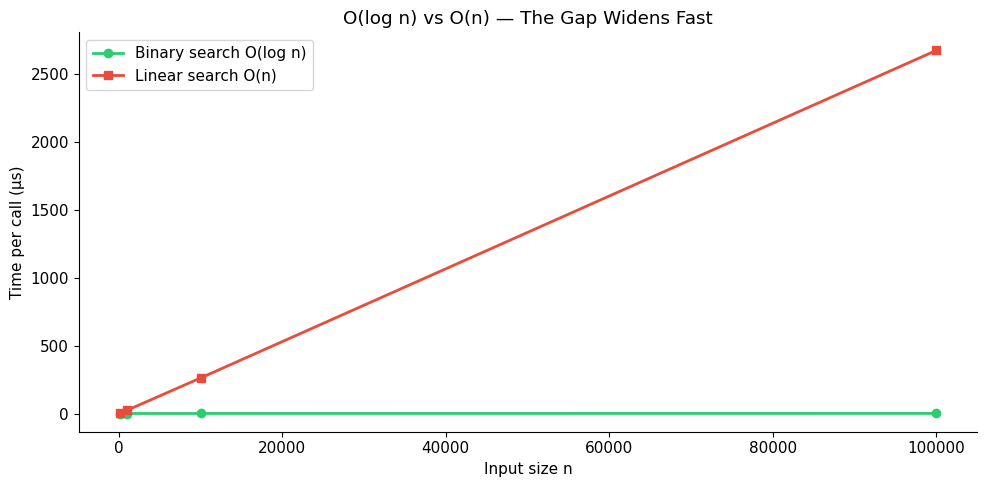

In [8]:
# Example 2: Contrast binary search vs linear search — timing

def linear_search(arr, target):
    """O(n) — scans every element."""
    for i, x in enumerate(arr):
        if x == target:
            return i
    return -1

sizes = [100, 1_000, 10_000, 100_000]
t_binary, t_linear = [], []

for n in sizes:
    arr = list(range(n))
    worst = n + 1  # not in array → forces full scan / all steps

    tb = timeit.timeit(lambda: binary_search(arr, worst), number=10_000) / 10_000
    tl = timeit.timeit(lambda: linear_search(arr, worst), number=1_000) / 1_000

    t_binary.append(tb * 1e6)
    t_linear.append(tl * 1e6)

fig, ax = plt.subplots()
ax.plot(sizes, t_binary, "o-", label="Binary search O(log n)", color="#2ecc71", linewidth=2)
ax.plot(sizes, t_linear, "s-", label="Linear search O(n)",    color="#e74c3c", linewidth=2)
ax.set_xlabel("Input size n")
ax.set_ylabel("Time per call (µs)")
ax.set_title("O(log n) vs O(n) — The Gap Widens Fast")
ax.legend()
plt.tight_layout()
plt.show()

### Exercises — O(1) and O(log n)

In [9]:
# Exercise 3.1
# Implement `contains_fast(word_set, word)` using a Python set
# and `contains_slow(word_list, word)` using a list.
#
# Both check if `word` is in the collection.
#
# Then time BOTH for n = [1_000, 10_000, 100_000, 500_000] words,
# always searching for a word NOT in the collection (worst case).
# Plot the results and explain why one is O(1) and the other O(n).

# YOUR CODE HERE


In [ ]:
# Exercise 3.2
# Implement your OWN binary search `my_binary_search(arr, target)`
# WITHOUT looking at the example above.
#
# Then verify it gives the same answer as Python's built-in
# `bisect.bisect_left` for 1000 random test cases on a sorted list.
#
# Finally, count the number of comparisons your implementation makes
# for n = [10, 100, 1000, 10000] and verify it grows as log₂(n).

import bisect

# YOUR CODE HERE


In [ ]:
# Exercise 3.3
# The function below finds the integer square root (floor) of n
# using a LINEAR scan. Rewrite it as `isqrt_log(n)` using
# binary search so it runs in O(log n).
#
# Verify both give the same answers for n in range(0, 10_000).
# Then time both for n = 10**12 and show the speedup.

def isqrt_linear(n):
    """O(√n) — counts up until i² > n."""
    i = 0
    while (i + 1) ** 2 <= n:
        i += 1
    return i

def isqrt_log(n):
    """TODO: O(log n) binary search version."""
    pass  # YOUR CODE HERE

# Verification
# for i in range(10_000):
#     assert isqrt_linear(i) == isqrt_log(i), f"Mismatch at {i}"
# print("All correct!")


## 4. O(n) — Linear Time

An algorithm is **O(n)** if it visits each element a **fixed number of times**.
Doubling `n` doubles the runtime — a proportional, predictable relationship.

**Common patterns:**
- A single `for` loop over the input
- Finding the max / min / sum
- Counting occurrences
- Building a hash map in one pass

In [ ]:
# Example 1: Classic O(n) — find max, count, sum

def find_max(lst):
    """O(n) — must look at every element."""
    if not lst:
        raise ValueError("Empty list")
    current_max = lst[0]
    for item in lst[1:]:
        if item > current_max:
            current_max = item
    return current_max

def count_occurrences(lst, target):
    """O(n) — single pass."""
    count = 0
    for item in lst:
        if item == target:
            count += 1
    return count

# Timing confirms linear growth
sizes = [10_000, 50_000, 100_000, 500_000, 1_000_000]
times = []

for n in sizes:
    data = [random.randint(0, 1000) for _ in range(n)]
    t = timeit.timeit(lambda: find_max(data), number=100) / 100
    times.append(t * 1000)  # ms

fig, ax = plt.subplots()
ax.plot(sizes, times, "o-", color="#f39c12", linewidth=2)
ax.set_xlabel("Input size n")
ax.set_ylabel("Time (ms)")
ax.set_title("O(n) — Runtime grows linearly with input")
plt.tight_layout()
plt.show()

(0, 1)
(0, 1)


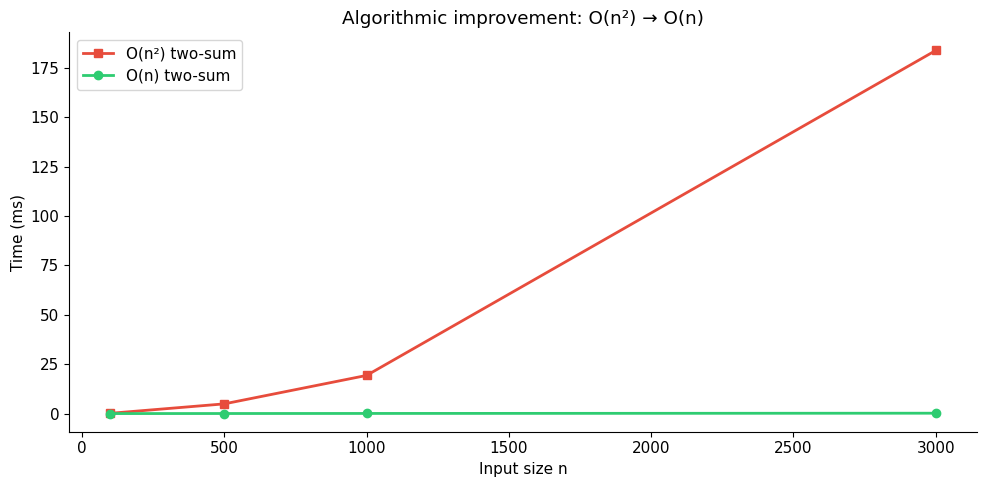

In [10]:
# Example 2: O(n) — Two-sum using a hash map (one pass)
# Problem: find two numbers in a list that add up to `target`.
#
# Naïve approach: check all pairs → O(n²)
# Smart approach: use a dict to remember what we've seen → O(n)

def two_sum_quadratic(nums, target):
    """O(n²) — check every pair."""
    for i in range(len(nums)):
        for j in range(i + 1, len(nums)):
            if nums[i] + nums[j] == target:
                return (i, j)
    return None

def two_sum_linear(nums, target):
    """O(n) — single pass with a lookup table."""
    seen = {}   # value → index
    for i, num in enumerate(nums):
        complement = target - num
        if complement in seen:
            return (seen[complement], i)
        seen[num] = i
    return None

# Correctness check
test = [2, 7, 11, 15]
print(two_sum_quadratic(test, 9))  # (0, 1)
print(two_sum_linear(test, 9))     # (0, 1)

# Timing comparison
sizes = [100, 500, 1_000, 3_000]
t_quad, t_lin = [], []

for n in sizes:
    data = list(range(n))          # target not present → worst case
    target = n * 3

    tq = timeit.timeit(lambda: two_sum_quadratic(data, target), number=200) / 200
    tl = timeit.timeit(lambda: two_sum_linear(data, target),    number=5_000) / 5_000

    t_quad.append(tq * 1000)
    t_lin.append(tl * 1000)

fig, ax = plt.subplots()
ax.plot(sizes, t_quad, "s-", label="O(n²) two-sum", color="#e74c3c", linewidth=2)
ax.plot(sizes, t_lin,  "o-", label="O(n) two-sum",  color="#2ecc71", linewidth=2)
ax.set_xlabel("Input size n")
ax.set_ylabel("Time (ms)")
ax.set_title("Algorithmic improvement: O(n²) → O(n)")
ax.legend()
plt.tight_layout()
plt.show()

### Exercises — O(n)

In [ ]:
# Exercise 4.1
# Below are two ways to check if a list has any duplicate values.
#   - `has_duplicates_slow`: compare all pairs — O(n²)
#   - Your task: write `has_duplicates_fast` in O(n) using a set.
#
# Verify they return the same results for 500 random test cases.
# Then time both for n = [100, 500, 1000, 3000] and plot the difference.

def has_duplicates_slow(lst):
    for i in range(len(lst)):
        for j in range(i + 1, len(lst)):
            if lst[i] == lst[j]:
                return True
    return False

def has_duplicates_fast(lst):
    pass  # YOUR CODE HERE

# YOUR TIMING / PLOT CODE HERE


In [ ]:
# Exercise 4.2
# Write an O(n) function `most_frequent(lst)` that returns the
# most frequently occurring element in a list.
# If there's a tie, return any one of the tied elements.
#
# You may only use a single pass over the list (no sorting!).
# Hint: use a dict to count, then find the max.
#
# Test cases:
#   most_frequent([1, 3, 2, 3, 1, 3])  → 3
#   most_frequent(["a", "b", "a", "c"]) → "a"
#   most_frequent([7])                  → 7

# YOUR CODE HERE


In [ ]:
# Exercise 4.3 — Kadane's Algorithm (classic O(n) problem)
# Given a list of integers (can include negatives),
# find the contiguous subarray with the largest sum.
#
# The naïve approach tries all subarrays → O(n²) or O(n³).
# Kadane's algorithm solves it in O(n).
#
# Implement `max_subarray_sum(nums)` using Kadane's algorithm.
# It should return the maximum sum (an integer).
#
# Test cases:
#   max_subarray_sum([-2, 1, -3, 4, -1, 2, 1, -5, 4]) → 6  (subarray: [4,-1,2,1])
#   max_subarray_sum([1])                               → 1
#   max_subarray_sum([-1, -2, -3])                      → -1
#
# Hint: at each position, decide: extend the current subarray, or start fresh?

# YOUR CODE HERE


## 5. O(n²) and O(n^k) — Polynomial Time

**Polynomial** algorithms have runtimes like n², n³, or n^k. They arise from **nested loops** — one loop inside another.

- **O(n²):** 2 nested loops → sorting algorithms like Bubble/Insertion/Selection sort, all-pairs comparison
- **O(n³):** 3 nested loops → naïve matrix multiplication

Polynomial algorithms become **very slow** for large `n`. Avoid them when an O(n log n) or O(n) alternative exists.

In [ ]:
# Example 1: Bubble sort — O(n²)

def bubble_sort(arr):
    """O(n²) — classic nested-loop sort."""
    arr = arr[:]   # don't mutate original
    n = len(arr)
    for i in range(n):
        for j in range(0, n - i - 1):
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
    return arr

# Compare with Python's built-in Timsort (O(n log n))
sizes = [200, 500, 1_000, 2_000, 4_000]
t_bubble, t_builtin = [], []

for n in sizes:
    data = [random.randint(0, 10_000) for _ in range(n)]

    tb = timeit.timeit(lambda: bubble_sort(data), number=10) / 10
    ts = timeit.timeit(lambda: sorted(data),      number=100) / 100

    t_bubble.append(tb * 1000)
    t_builtin.append(ts * 1000)

fig, ax = plt.subplots()
ax.plot(sizes, t_bubble,  "s-", label="Bubble sort O(n²)",         color="#e74c3c", linewidth=2)
ax.plot(sizes, t_builtin, "o-", label="Python sorted() O(n log n)", color="#2ecc71", linewidth=2)
ax.set_xlabel("Input size n")
ax.set_ylabel("Time (ms)")
ax.set_title("O(n²) vs O(n log n) — Bubble sort vs Timsort")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Example 2: Spotting O(n²) in "innocent-looking" code
# These patterns are common bugs in beginner code.

# ❌ O(n²) — string concatenation in a loop
def build_string_slow(words):
    result = ""
    for w in words:          # each += copies the entire string!
        result += w + " "
    return result.strip()

# ✅ O(n)  — collect then join
def build_string_fast(words):
    return " ".join(words)

# ❌ O(n²) — repeated `in` checks on a list inside a loop
def unique_slow(lst):
    seen = []
    for x in lst:
        if x not in seen:    # list `in` is O(n)! → O(n²) total
            seen.append(x)
    return seen

# ✅ O(n)  — use a set
def unique_fast(lst):
    seen = set()
    result = []
    for x in lst:
        if x not in seen:    # set `in` is O(1) → O(n) total
            seen.add(x)
            result.append(x)
    return result

# Quick timing demo
words = [f"word{i}" for i in range(3_000)]
nums  = list(range(3_000)) + list(range(1_500))  # with duplicates

t_slow_str  = timeit.timeit(lambda: build_string_slow(words), number=50)  / 50 * 1000
t_fast_str  = timeit.timeit(lambda: build_string_fast(words), number=500) / 500 * 1000
t_slow_uniq = timeit.timeit(lambda: unique_slow(nums), number=100) / 100 * 1000
t_fast_uniq = timeit.timeit(lambda: unique_fast(nums), number=500) / 500 * 1000

print(f"String concat  — slow: {t_slow_str:.3f}ms  fast: {t_fast_str:.3f}ms  speedup: {t_slow_str/t_fast_str:.0f}x")
print(f"Unique (n=4500) — slow: {t_slow_uniq:.3f}ms  fast: {t_fast_uniq:.3f}ms  speedup: {t_slow_uniq/t_fast_uniq:.0f}x")

### Exercises — O(n²)

In [ ]:
# Exercise 5.1
# Count the comparisons made by selection sort and insertion sort
# for n = [10, 50, 100, 200, 500].
#
# Both are O(n²) — but do they make the same number of comparisons?
# Plot comparison count vs n for both, and add a reference O(n²) curve.
#
# Implement both sorting algorithms (add a `comparisons` counter).

def selection_sort(arr):
    arr = arr[:]
    comparisons = 0
    # YOUR CODE HERE
    return arr, comparisons

def insertion_sort(arr):
    arr = arr[:]
    comparisons = 0
    # YOUR CODE HERE
    return arr, comparisons

# YOUR PLOT CODE HERE


In [11]:
# Exercise 5.2
# The function `all_pairs_sum(lst)` below is O(n²).
# It returns a list of all unique sums of pairs (i < j).
#
# Your task: profile WHERE the time goes and answer:
#   a) How many pairs are there for n = 100? n = 1000? (formula: n*(n-1)/2)
#   b) Time it for n = [100, 300, 500, 1000] and verify it's quadratic
#      by checking if time roughly quadruples when n doubles.

def all_pairs_sum(lst):
    results = []
    for i in range(len(lst)):
        for j in range(i + 1, len(lst)):
            results.append(lst[i] + lst[j])
    return results

# YOUR CODE HERE


In [ ]:
# Exercise 5.3
# The function below checks if any two words in a list are anagrams of each other.
# It's O(n² × L) where L is average word length.
# Rewrite `has_anagram_pair_fast` to run in O(n × L) using a dict.
#
# Verify correctness and time both versions.

def has_anagram_pair_slow(words):
    """O(n²×L) — compare every pair."""
    for i in range(len(words)):
        for j in range(i + 1, len(words)):
            if sorted(words[i]) == sorted(words[j]):
                return True
    return False

def has_anagram_pair_fast(words):
    """TODO: O(n×L) — use a signature/key per word."""
    pass  # YOUR CODE HERE
    # Hint: two words are anagrams iff sorted(word) is equal

# Test
print(has_anagram_pair_slow(["cat", "dog", "act"]))  # True
print(has_anagram_pair_slow(["hello", "world"]))     # False


## 6. O(2ⁿ) and O(n!) — Exponential & Factorial

These classes are **intractable** for large inputs — even `n = 50` can take longer than the age of the universe.

| n | O(2ⁿ) operations | O(n!) operations |
|---|---|---|
| 10 | 1,024 | 3,628,800 |
| 20 | 1,048,576 | 2.4 × 10¹⁸ |
| 30 | ~10⁹ | ~10³² |

**O(2ⁿ) examples:**
- Naïve recursive Fibonacci (computes the same subproblems over and over)
- Finding all subsets of a set

**O(n!) examples:**
- Brute-force Travelling Salesman (trying all routes)
- Generating all permutations

In [13]:
# Example 1: Naïve Fibonacci — O(2ⁿ) due to repeated recomputation

call_counter = {"n": 0}

def fib_naive(n):
    """O(2ⁿ) — recomputes the same values exponentially many times."""
    call_counter["n"] += 1
    if n <= 1:
        return n
    return fib_naive(n - 1) + fib_naive(n - 2)

print(f"{'n':>5}  {'calls':>12}  {'2^n':>12}")
print("-" * 35)
for n in [5, 10, 15, 20, 25]:
    call_counter["n"] = 0
    result = fib_naive(n)
    print(f"  {n:>3}  {call_counter['n']:>12,}  {2**n:>12,}")

    n         calls           2^n
-----------------------------------
    5            15            32
   10           177         1,024
   15         1,973        32,768
   20        21,891     1,048,576
   25       242,785    33,554,432


In [14]:
# Example 2: Fixing O(2ⁿ) → O(n) with memoization
import functools

@functools.lru_cache(maxsize=None)  # lru_cache stands for Least Recently Used cache
def fib_memo(n):
    """O(n) — each subproblem computed exactly once."""
    if n <= 1:
        return n
    return fib_memo(n - 1) + fib_memo(n - 2)

# Timing comparison (be careful: fib_naive(35) is already slow!)
import time

for n in [10, 20, 30]:
    t0 = time.perf_counter()
    r_naive = fib_naive(n)
    t_naive = time.perf_counter() - t0

    fib_memo.cache_clear()
    t0 = time.perf_counter()
    r_memo = fib_memo(n)
    t_memo = time.perf_counter() - t0

    assert r_naive == r_memo
    print(f"fib({n:2d})  naive: {t_naive*1000:8.3f}ms   memo: {t_memo*1000:.4f}ms   "
          f"speedup: {t_naive/max(t_memo, 1e-9):.0f}x")

fib(10)  naive:    0.019ms   memo: 0.0026ms   speedup: 7x
fib(20)  naive:    1.973ms   memo: 0.0052ms   speedup: 379x
fib(30)  naive:  243.537ms   memo: 0.0115ms   speedup: 21100x


### Exercises — Exponential & Memoization

In [ ]:
# Exercise 6.1
# The naïve recursive solution for counting ways to climb n stairs
# (taking 1 or 2 steps at a time) is O(2ⁿ).
#
# 1) Implement `climb_naive(n)` recursively.
# 2) Implement `climb_memo(n)` with memoization (use a dict or @lru_cache).
# 3) Implement `climb_dp(n)` iteratively in O(n) time and O(1) space.
#
# Verify all three agree for n in range(1, 20).
# Time all three for n = 30.
#
# Expected: climb(1)=1, climb(2)=2, climb(3)=3, climb(4)=5, climb(5)=8

# YOUR CODE HERE


In [ ]:
# Exercise 6.2
# `power_set(lst)` returns all possible subsets of lst.
# It's inherently O(2ⁿ) in output size — that's unavoidable.
#
# 1) Implement it recursively.
# 2) Implement it iteratively.
# 3) Count and print the number of subsets for n = [1,2,3,4,5,10,15,20].
#    Verify the count is always 2^n.
# 4) What is the largest n for which you can generate all subsets
#    in under 1 second on your machine? (try to find it!)
#
# power_set([1,2,3]) → [[], [1], [2], [3], [1,2], [1,3], [2,3], [1,2,3]]

# YOUR CODE HERE


In [ ]:
# Exercise 6.3
# The 0/1 Knapsack Problem:
# Given items with weights and values, find the most valuable
# subset that fits in a knapsack of capacity W.
# See also: https://en.wikipedia.org/wiki/Knapsack_problem#Definition
#
# 1) Implement `knapsack_naive(weights, values, W)` using brute-force
#    recursion — try all subsets → O(2ⁿ).
# 2) Implement `knapsack_dp(weights, values, W)` using dynamic programming
#    → O(n × W).
# 3) Verify both agree on the test case below.
# 4) Time both for n=20 items, W=50. What's the speedup?
#
# Test: weights=[1,3,4,5], values=[1,4,5,7], W=7 → answer: 9

# YOUR CODE HERE


# PART B — Profiling Tools

Theory tells us *what* to expect. Profiling tells us *what's actually happening*.

> **"Premature optimisation is the root of all evil."** — Knuth
>
> Always **measure first**, then optimise. Your intuition about where the bottleneck is will often be wrong.

## 7. `timeit` — Micro-Benchmarking

`timeit` is built into Python's stdlib. It runs a snippet many times and reports the best (or average) time, eliminating noise from the OS scheduler.

Use it for **quick A/B comparisons** of two implementations.

In [ ]:
# Example 1: timeit in Python code
import timeit

# Compare list comprehension vs map() vs explicit loop for squaring
data = list(range(10_000))

def using_loop():
    result = []
    for x in data:
        result.append(x ** 2)
    return result

def using_comprehension():
    return [x ** 2 for x in data]

def using_map():
    return list(map(lambda x: x ** 2, data))

N = 1_000
t_loop  = timeit.timeit(using_loop,          number=N) / N * 1000
t_comp  = timeit.timeit(using_comprehension, number=N) / N * 1000
t_map   = timeit.timeit(using_map,           number=N) / N * 1000

print(f"Explicit loop   : {t_loop:.3f} ms")
print(f"List comprehension: {t_comp:.3f} ms  ({t_loop/t_comp:.1f}x faster than loop)")
print(f"map()           : {t_map:.3f} ms  ({t_loop/t_map:.1f}x faster than loop)")

In [ ]:
# Example 2: %timeit magic in Jupyter (single-line and block)
# The %%timeit magic runs the whole cell many times automatically.

data = list(range(100_000))

%timeit sum(data)

In [ ]:
%%timeit
# This entire cell will be timed
data = list(range(10_000))
total = 0
for x in data:
    total += x

## 8. `pyinstrument` — Call-Stack Profiling

`pyinstrument` is a **sampling profiler** — it checks what your code is doing every few milliseconds and builds a picture of where time is spent, grouped by call stack.

**When to use it:** understanding the big picture — which functions are slow, and who called them.

**Key strengths:**
- Very low overhead (doesn't instrument every call)
- Beautiful, readable output
- Shows **wall-clock time** (including I/O waits)
- Works great in Jupyter with `Profiler` context manager

In [1]:
# Example 1: Basic pyinstrument usage
from pyinstrument import Profiler

def step_a(data):
    """Fast: O(n) sum."""
    return sum(data)

def step_b(data):
    """Slow: O(n²) all-pairs."""
    total = 0
    for i in range(len(data)):
        for j in range(len(data)):
            total += data[i] * data[j]
    return total

def step_c(data):
    """Medium: O(n log n) sort."""
    return sorted(data)

def run_pipeline(data):
    a = step_a(data)
    b = step_b(data)
    c = step_c(data)
    return a, b, c

data = list(range(2_000))

profiler = Profiler()
profiler.start()

run_pipeline(data)

profiler.stop()
profiler.print()   # prints a call tree to stdout


  _     ._   __/__   _ _  _  _ _/_   Recorded: 14:52:44  Samples:  202
 /_//_/// /_\ / //_// / //_'/ //     Duration: 0.213     CPU time: 0.212
/   _/                      v5.1.2

Profile at /var/folders/p0/70960vj9365cb_dnzrb01psrr0w14r/T/ipykernel_21292/4181563840.py:29

0.212 <module>  /var/folders/p0/70960vj9365cb_dnzrb01psrr0w14r/T/ipykernel_21292/4181563840.py:1
└─ 0.212 run_pipeline  /var/folders/p0/70960vj9365cb_dnzrb01psrr0w14r/T/ipykernel_21292/4181563840.py:20
   └─ 0.212 step_b  /var/folders/p0/70960vj9365cb_dnzrb01psrr0w14r/T/ipykernel_21292/4181563840.py:8




In [2]:
# Example 2: Using pyinstrument as a context manager
from pyinstrument import Profiler
import time

def fetch_data():
    time.sleep(0.05)    # simulate I/O
    return list(range(3_000))

def transform(data):
    return [x ** 2 for x in data]

def aggregate(data):
    # Intentionally inefficient for demo purposes
    result = []
    for x in data:
        if x not in result:  # O(n) per check → O(n²)
            result.append(x)
    return result

with Profiler() as profiler:
    raw   = fetch_data()
    clean = transform(raw)
    final = aggregate(clean)

# open=True would open an HTML report in the browser
profiler.print()


  _     ._   __/__   _ _  _  _ _/_   Recorded: 14:53:00  Samples:  23
 /_//_/// /_\ / //_// / //_'/ //     Duration: 0.074     CPU time: 0.024
/   _/                      v5.1.2

Profile at /var/folders/p0/70960vj9365cb_dnzrb01psrr0w14r/T/ipykernel_21292/1468326754.py:20

0.074 <module>  /var/folders/p0/70960vj9365cb_dnzrb01psrr0w14r/T/ipykernel_21292/1468326754.py:1
├─ 0.052 fetch_data  /var/folders/p0/70960vj9365cb_dnzrb01psrr0w14r/T/ipykernel_21292/1468326754.py:5
│  └─ 0.052 sleep  <built-in>
└─ 0.022 aggregate  /var/folders/p0/70960vj9365cb_dnzrb01psrr0w14r/T/ipykernel_21292/1468326754.py:12




In [4]:
# Example 3: pyinstrument HTML report (opens in browser)
# Uncomment and run to see the interactive flamegraph in a browser tab.

# with Profiler() as p:
#     run_pipeline(list(range(2_000)))
# p.open_in_browser()

### Exercises — pyinstrument

In [ ]:
# Exercise 8.1
# The pipeline below has a hidden bottleneck.
# Use pyinstrument to find which step is slowest, then explain WHY.
#
# After identifying the bottleneck, write a fixed version
# `process_fast(records)` and verify with pyinstrument that the
# problem is gone.

import time, random, string

def generate_records(n):
    return [{"id": i, "value": random.randint(1, 100), "tag": random.choice(list("ABCD"))}
            for i in range(n)]

def filter_high_value(records):
    return [r for r in records if r["value"] > 50]

def deduplicate_ids(records):
    """Remove records with duplicate IDs."""
    seen_ids = []
    result = []
    for r in records:
        if r["id"] not in seen_ids:   # ← suspicious?
            seen_ids.append(r["id"])
            result.append(r)
    return result

def format_output(records):
    output = ""
    for r in records:
        output += f"id={r['id']} value={r['value']} tag={r['tag']}\n"  # ← suspicious?
    return output

def process(records):
    filtered  = filter_high_value(records)
    deduped   = deduplicate_ids(filtered)
    formatted = format_output(deduped)
    return formatted

records = generate_records(5_000)

# YOUR PROFILING + FIX CODE HERE


In [ ]:
# Exercise 8.2
# Use pyinstrument to profile the recursive `fib_naive(n)` from earlier
# with n=28. Then profile `fib_memo(n)` with n=28.
# Print both profiles side-by-side and comment on:
#   a) What does the call tree look like for fib_naive?
#   b) What does the call tree look like for fib_memo?
#   c) What is the speedup?

# YOUR CODE HERE


In [ ]:
# Exercise 8.3
# Write a function `matrix_ops(n)` that:
#   1. Creates two n×n matrices of random floats (use nested lists, no numpy)
#   2. Adds them element-wise → result_add
#   3. Multiplies them (naïve triple loop) → result_mul
#   4. Computes row sums of result_mul → sums
#   5. Returns sums
#
# Profile it with pyinstrument for n=100.
# Which step dominates? What's its theoretical complexity?
# Can you reduce the time of steps 1-2 without numpy? Try.

# YOUR CODE HERE


## 9.`line_profiler` — Line-by-Line Profiling

`line_profiler` instruments **every line** of a function and shows exactly how much time each line takes.

**When to use it:** once pyinstrument has pointed you at a specific function, use `line_profiler` to find the exact hot line(s) inside it.

**In Jupyter:** use the `%lprun` magic.

**Columns in the output:**
- `Hits` — how many times the line ran
- `Time` — total time (in µs or timer units)
- `Per Hit` — time per single execution
- `% Time` — share of the function's total time ← **focus here**

In [1]:
# Setup: load the line_profiler Jupyter extension
%load_ext line_profiler
print("line_profiler loaded. Use %lprun to profile.")

line_profiler loaded. Use %lprun to profile.


In [2]:
# Example 1: Profile a function line by line
# Syntax: %lprun -f function_to_profile  call_that_invokes_it

def process_numbers(data):
    """Several operations — which line is the bottleneck?"""
    filtered = [x for x in data if x % 2 == 0]   # keep evens
    squared  = [x ** 2 for x in filtered]          # square them
    unique   = list(set(squared))                  # deduplicate
    unique.sort()                                  # sort in place
    total    = sum(unique)                         # sum
    return total

data = list(range(100_000))

%lprun -f process_numbers process_numbers(data)

In [3]:
# Example 2: Profile multiple functions at once with -f

def tokenize(text):
    return text.lower().split()

def count_words(tokens):
    counts = {}
    for token in tokens:
        counts[token] = counts.get(token, 0) + 1
    return counts

def top_n(counts, n=10):
    return sorted(counts.items(), key=lambda x: x[1], reverse=True)[:n]

def word_frequency_pipeline(text):
    tokens = tokenize(text)
    counts = count_words(tokens)
    top    = top_n(counts)
    return top

# Build a big text
words_vocab = ["python", "fast", "slow", "loop", "list", "dict", "set", "code"]
big_text = " ".join(random.choices(words_vocab, k=200_000))

# Profile all four functions in one shot
%lprun -f word_frequency_pipeline -f tokenize -f count_words -f top_n  word_frequency_pipeline(big_text)

NameError: name 'random' is not defined

In [4]:
# Example 3: line_profiler without Jupyter magic (programmatic)
from line_profiler import LineProfiler

def slow_function(data):
    result = []
    for x in data:
        if x ** 0.5 > 100:           # expensive condition
            result.append(str(x))     # string conversion
    joined = ", ".join(result)
    return joined

lp = LineProfiler()
lp.add_function(slow_function)
lp_wrapper = lp(slow_function)

lp_wrapper(list(range(100_000)))
lp.print_stats()

Timer unit: 1e-09 s

Total time: 0.064197 s
File: /var/folders/p0/70960vj9365cb_dnzrb01psrr0w14r/T/ipykernel_21363/2564880554.py
Function: slow_function at line 4

Line #      Hits         Time  Per Hit   % Time  Line Contents
     4                                           def slow_function(data):
     5         1          0.0      0.0      0.0      result = []
     6    100001   18112000.0    181.1     28.2      for x in data:
     7    100000   23003000.0    230.0     35.8          if x ** 0.5 > 100:           # expensive condition
     8     89999   22233000.0    247.0     34.6              result.append(str(x))     # string conversion
     9         1     848000.0 848000.0      1.3      joined = ", ".join(result)
    10         1       1000.0   1000.0      0.0      return joined



### Exercises — line_profiler

In [ ]:
# Exercise 9.1
# Profile `compute_stats` below using %lprun.
# Identify which line takes the most time and why.
# Then rewrite it as `compute_stats_fast` — fixing only that line.
# Use %lprun again to confirm the improvement.

def compute_stats(data):
    n      = len(data)
    mean   = sum(data) / n
    # Variance: average of squared deviations
    sq_dev = [(x - mean) ** 2 for x in data]
    var    = sum(sq_dev) / n
    std    = var ** 0.5
    sorted_data = sorted(data)
    median = sorted_data[n // 2]
    return {"mean": mean, "std": std, "median": median}

data = [random.gauss(50, 15) for _ in range(100_000)]

# Profile it:
# %lprun -f compute_stats compute_stats(data)

# YOUR FAST VERSION + SECOND %lprun HERE


In [ ]:
# Exercise 9.2
# The function `find_common_elements` finds elements present in ALL
# given lists. Profile it with %lprun and identify the bottleneck.
#
# Then write `find_common_fast` using set intersection and verify:
#   a) Both return the same result
#   b) %lprun shows the fix is faster

def find_common_elements(lists):
    if not lists:
        return []
    common = lists[0][:]
    for lst in lists[1:]:
        new_common = []
        for item in common:
            if item in lst:          # ← what's the complexity here?
                new_common.append(item)
        common = new_common
    return common

# Test data
import random
lists = [random.choices(range(500), k=1000) for _ in range(10)]

# %lprun -f find_common_elements find_common_elements(lists)

# YOUR FAST VERSION HERE


In [ ]:
# Exercise 9.3
# Profile the `run_simulation` function using BOTH pyinstrument
# (for the high-level picture) AND %lprun (for line-level detail).
#
# Write a brief comment explaining what each tool told you
# that the other didn't.

def roll_dice(n):
    return [random.randint(1, 6) for _ in range(n)]

def compute_histogram(rolls):
    hist = {i: 0 for i in range(1, 7)}
    for r in rolls:
        hist[r] += 1
    return hist

def detect_streaks(rolls, length=3):
    """Find all positions where the same value repeats `length` times."""
    streaks = []
    for i in range(len(rolls) - length + 1):
        window = rolls[i:i + length]
        if len(set(window)) == 1:
            streaks.append((i, window[0]))
    return streaks

def run_simulation(n_rolls=50_000):
    rolls   = roll_dice(n_rolls)
    hist    = compute_histogram(rolls)
    streaks = detect_streaks(rolls)
    return hist, len(streaks)

# YOUR PROFILING CODE HERE


# PART C — Optimisation Challenges

## 10. Intermediate Optimisation Exercises

For each challenge below:
1. **Profile the slow version** (pyinstrument and/or %lprun)
2. **Identify the bottleneck** and its complexity
3. **Write the optimised version**
4. **Verify correctness** and **measure the speedup**

> Common optimisation strategies:
> - Replace list membership `in` with set membership O(1)
> - Replace string `+=` with `"".join()`
> - Cache repeated results with `@lru_cache` or a dict
> - Reduce nested loops with hash maps
> - Prefer generators over materialising full lists when possible
> - Sort once and reuse vs re-sorting repeatedly

In [ ]:
# Optimisation Challenge 1 — The Slow Report Generator
#
# `generate_report(records)` is used daily on datasets of ~10,000 records.
# It's become painfully slow. Profile it, find the bottlenecks, and
# produce `generate_report_fast(records)` that achieves at least a 20× speedup.
#
# Rules: output must be identical. No external libraries.

import random, string

def make_records(n=10_000):
    categories = ["electronics", "clothing", "food", "books", "sports"]
    return [
        {
            "id":       i,
            "name":     "".join(random.choices(string.ascii_lowercase, k=8)),
            "category": random.choice(categories),
            "price":    round(random.uniform(1, 500), 2),
            "sold":     random.randint(0, 1000),
        }
        for i in range(n)
    ]

def generate_report(records):
    # Part 1: Build a category summary string (slow!)
    report = ""
    for r in records:
        report += f"{r['id']},{r['category']},{r['price']}\n"  # quadratic!

    # Part 2: For each record, check if it's a "top seller"
    # (sold more than average) — uses a list for tracking seen categories
    all_sold = [r["sold"] for r in records]
    avg_sold = sum(all_sold) / len(all_sold)

    top_sellers = []
    seen_names = []  # track names already added
    for r in records:
        if r["sold"] > avg_sold:
            if r["name"] not in seen_names:   # O(n) lookup!
                seen_names.append(r["name"])
                top_sellers.append(r)

    # Part 3: Category revenue (recomputed from scratch per category)
    categories = list({r["category"] for r in records})
    category_revenue = {}
    for cat in categories:
        revenue = 0
        for r in records:                   # O(n) per category!
            if r["category"] == cat:
                revenue += r["price"] * r["sold"]
        category_revenue[cat] = revenue

    return report, top_sellers, category_revenue

records = make_records(5_000)

# Step 1: Profile it
# from pyinstrument import Profiler
# with Profiler() as p:
#     generate_report(records)
# p.print()

# Step 2: Write generate_report_fast(records)
# YOUR CODE HERE

# Step 3: Verify + measure speedup
# YOUR CODE HERE


In [ ]:
# Optimisation Challenge 2 — The Slow Autocomplete
#
# `find_suggestions(word_list, prefix)` returns all words that start
# with `prefix`. It's called thousands of times per second in production.
#
# The slow version scans the entire word list every call.
# Your tasks:
#   a) Confirm it's O(n × L) per query where L = avg word length.
#   b) Write a `build_prefix_index(word_list)` that pre-processes words
#      into a dict of prefix → list of words, so that lookup is O(1).
#   c) Write `find_suggestions_fast(index, prefix)` using the index.
#   d) Profile and compare. What's the speedup per query?
#      What's the tradeoff (hint: think about memory and setup time)?

import urllib.request

# Load a real English word list (~235,000 words)
url = "https://raw.githubusercontent.com/dwyl/english-words/master/words_alpha.txt"
try:
    with urllib.request.urlopen(url, timeout=5) as f:
        word_list = f.read().decode().splitlines()
    print(f"Loaded {len(word_list):,} words from the internet.")
except Exception:
    # Fallback: generate a synthetic word list
    import random, string
    word_list = ["".join(random.choices(string.ascii_lowercase, k=random.randint(3,10)))
                 for _ in range(50_000)]
    print(f"Using {len(word_list):,} synthetic words.")

def find_suggestions(word_list, prefix):
    """O(n × L) per query — scans all words."""
    return [w for w in word_list if w.startswith(prefix)]

# YOUR OPTIMISED VERSION HERE


In [ ]:
# Optimisation Challenge 3 — The Slow Graph BFS
#
# Breadth-First Search (BFS) finds shortest paths in an unweighted graph.
# The implementation below has a subtle O(n²) bug despite BFS being O(V+E).
#
# Tasks:
#   a) Profile `bfs_slow` with pyinstrument and %lprun. Find the bug.
#   b) Fix it in `bfs_fast`. It should be O(V + E).
#   c) Verify both return identical shortest-path distances.
#   d) Show the speedup on a random graph with 2000 nodes.

from collections import defaultdict, deque

def build_graph(n_nodes=500, n_edges=2000):
    graph = defaultdict(list)
    for _ in range(n_edges):
        u = random.randint(0, n_nodes - 1)
        v = random.randint(0, n_nodes - 1)
        if u != v:
            graph[u].append(v)
            graph[v].append(u)
    return graph

def bfs_slow(graph, start):
    """Returns dict of {node: shortest_distance_from_start}."""
    distances = {start: 0}
    queue = [start]          # ← using a list as a queue
    visited = []             # ← using a list to track visited

    while queue:
        node = queue.pop(0)              # ← O(n) — dequeue from front of list!
        if node in visited:              # ← O(n) — list membership!
            continue
        visited.append(node)             # ← O(1) append is fine
        for neighbour in graph[node]:
            if neighbour not in visited: # ← O(n) — list membership again!
                if neighbour not in distances:
                    distances[neighbour] = distances[node] + 1
                queue.append(neighbour)
    return distances

def bfs_fast(graph, start):
    """TODO: Fix the O(n²) bugs. Use deque and set."""
    pass  # YOUR CODE HERE

# YOUR PROFILING + VERIFICATION + SPEEDUP CODE HERE


In [ ]:
# Optimisation Challenge 4 — The Slow Log Parser
#
# A log parser reads millions of lines and builds statistics.
# Profile, identify, and fix ALL bottlenecks.
# Target: at least 15× speedup over the original.

import re, random, time

def generate_logs(n=100_000):
    levels = ["INFO", "WARNING", "ERROR", "DEBUG"]
    services = ["auth", "payment", "search", "delivery", "api"]
    logs = []
    for i in range(n):
        lvl = random.choice(levels)
        svc = random.choice(services)
        ms  = random.randint(1, 5000)
        logs.append(f"[{lvl}] service={svc} duration={ms}ms request_id={i}")
    return logs

def parse_logs_slow(log_lines):
    error_lines    = []
    service_counts = {}
    slow_requests  = []   # duration > 1000ms

    for line in log_lines:
        # Expensive: re.compile inside the loop recompiles every iteration
        level_match = re.search(r"\[(\w+)\]", line)
        svc_match   = re.search(r"service=(\w+)", line)
        dur_match   = re.search(r"duration=(\d+)ms", line)

        if not (level_match and svc_match and dur_match):
            continue

        level    = level_match.group(1)
        service  = svc_match.group(1)
        duration = int(dur_match.group(1))

        if level == "ERROR":
            error_lines = error_lines + [line]  # creates a new list each time!

        if service not in service_counts:
            service_counts[service] = 0
        service_counts[service] += 1

        if duration > 1000:
            slow_requests = slow_requests + [(service, duration)]  # same bug!

    return error_lines, service_counts, slow_requests

logs = generate_logs(30_000)

# Profile:
# from pyinstrument import Profiler
# with Profiler() as p:
#     parse_logs_slow(logs)
# p.print()

# %lprun -f parse_logs_slow parse_logs_slow(logs)

# YOUR OPTIMISED VERSION + SPEEDUP MEASUREMENT HERE


In [ ]:
# Optimisation Challenge 5 — The Slow Recommendation Engine
#
# This function computes a "similarity score" between a target user
# and every other user, then returns the top-k most similar.
# It works but is unusably slow for large user bases.
#
# Your tasks:
#   a) Profile it. Identify all inefficiencies.
#   b) Rewrite `recommend_fast` with at least a 30× speedup.
#   c) Bonus: can you use sets to compute Jaccard similarity in O(|A|+|B|)?

import math

def generate_users(n_users=500, n_items=200):
    items = [f"item_{i}" for i in range(n_items)]
    return {
        f"user_{u}": set(random.choices(items, k=random.randint(5, 50)))
        for u in range(n_users)
    }

def jaccard_slow(set_a, set_b):
    """Jaccard similarity: |A ∩ B| / |A ∪ B|."""
    # Converts to lists unnecessarily
    list_a, list_b = list(set_a), list(set_b)
    intersection = [x for x in list_a if x in list_b]  # O(|A| × |B|)!
    union = list_a[:]
    for x in list_b:
        if x not in union:   # O(|union|) per item!
            union.append(x)
    if not union:
        return 0.0
    return len(intersection) / len(union)

def recommend_slow(users, target_user, top_k=5):
    target_items = users[target_user]
    scores = []
    for user, items in users.items():
        if user == target_user:
            continue
        score = jaccard_slow(target_items, items)
        scores = scores + [(user, score)]   # list concatenation bug!
    # Sort scores from scratch each time (here it's only once, but still)
    scores_sorted = []
    for i in range(len(scores)):
        scores_sorted.append(scores[i])
    scores_sorted.sort(key=lambda x: x[1], reverse=True)
    return scores_sorted[:top_k]

users = generate_users(300, 150)

# YOUR PROFILING + FAST VERSION + SPEEDUP CODE HERE


## Summary Cheat Sheet

### Complexity Classes

| Class | Name | Doubles n → | Python pattern |
|---|---|---|---|
| O(1) | Constant | Same time | `dict[key]`, `set.add()`, `list[i]` |
| O(log n) | Logarithmic | +1 step | Binary search, balanced BST |
| O(n) | Linear | 2× time | Single loop, `sum()`, `max()` |
| O(n log n) | Linearithmic | ~2× time | `sorted()`, merge sort |
| O(n²) | Quadratic | 4× time | Nested loops, `x in list` inside loop |
| O(2ⁿ) | Exponential | Doubles per step | Naive recursion without memoization |
| O(n!) | Factorial | n× time | Brute-force permutations |

### Common Slowness Patterns & Fixes

```python
# ❌ O(n) list membership inside a loop → O(n²)
for x in data:
    if x in my_list:   # slow!

# ✅ Use a set
my_set = set(my_list)
for x in data:
    if x in my_set:    # O(1)

# ❌ String concatenation in a loop → O(n²)
result = ""
for s in strings:
    result += s        # copies the whole string!

# ✅ Collect then join → O(n)
result = "".join(strings)

# ❌ Repeated work inside a loop
for x in data:
    if x in expensive_list():  # recomputed each iteration!

# ✅ Compute once
cache = set(expensive_list())
for x in data:
    if x in cache:

# ❌ Naive recursion → O(2ⁿ)
def fib(n): return fib(n-1) + fib(n-2)

# ✅ Memoize → O(n)
@functools.lru_cache(maxsize=None)
def fib(n): return fib(n-1) + fib(n-2)

# ❌ list.pop(0) — O(n) front deletion
queue = []; queue.pop(0)

# ✅ collections.deque — O(1) front deletion
from collections import deque
queue = deque(); queue.popleft()
```

### Profiling Workflow

```
1. pyinstrument → Which FUNCTION is slow? (big picture)
2. %lprun       → Which LINE inside that function? (surgical)
3. timeit       → Is my fix actually faster? (measure the speedup)
4. Repeat
```

```python
# pyinstrument — context manager style
from pyinstrument import Profiler
with Profiler() as p:
    my_function(data)
p.print()

# line_profiler — Jupyter magic
%load_ext line_profiler
%lprun -f my_function  my_function(data)

# timeit — quick comparison
import timeit
t = timeit.timeit(lambda: my_function(data), number=1000) / 1000
# or in Jupyter:
%timeit my_function(data)
```